In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/customer_churn_dataset-testing-master.csv')
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         64374 non-null  int64 
 1   Age                64374 non-null  int64 
 2   Gender             64374 non-null  object
 3   Tenure             64374 non-null  int64 
 4   Usage Frequency    64374 non-null  int64 
 5   Support Calls      64374 non-null  int64 
 6   Payment Delay      64374 non-null  int64 
 7   Subscription Type  64374 non-null  object
 8   Contract Length    64374 non-null  object
 9   Total Spend        64374 non-null  int64 
 10  Last Interaction   64374 non-null  int64 
 11  Churn              64374 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 5.9+ MB


CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

In [4]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='object')

In [5]:
df.columns = df.columns.str.replace(" ", "_")
df.columns = df.columns.str.lower()

df.columns

Index(['customerid', 'age', 'gender', 'tenure', 'usage_frequency',
       'support_calls', 'payment_delay', 'subscription_type',
       'contract_length', 'total_spend', 'last_interaction', 'churn'],
      dtype='object')

In [6]:
df.isnull().sum()

customerid           0
age                  0
gender               0
tenure               0
usage_frequency      0
support_calls        0
payment_delay        0
subscription_type    0
contract_length      0
total_spend          0
last_interaction     0
churn                0
dtype: int64

In [7]:
df.fillna(method='ffill', inplace=True)

In [8]:
df.duplicated().sum()

0

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   customerid         64374 non-null  int64 
 1   age                64374 non-null  int64 
 2   gender             64374 non-null  object
 3   tenure             64374 non-null  int64 
 4   usage_frequency    64374 non-null  int64 
 5   support_calls      64374 non-null  int64 
 6   payment_delay      64374 non-null  int64 
 7   subscription_type  64374 non-null  object
 8   contract_length    64374 non-null  object
 9   total_spend        64374 non-null  int64 
 10  last_interaction   64374 non-null  int64 
 11  churn              64374 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 5.9+ MB


In [10]:
df['age'] = pd.to_numeric(df['age'], errors='coerce')

In [11]:
df.columns

Index(['customerid', 'age', 'gender', 'tenure', 'usage_frequency',
       'support_calls', 'payment_delay', 'subscription_type',
       'contract_length', 'total_spend', 'last_interaction', 'churn'],
      dtype='object')

In [12]:
df['churn'].value_counts()

churn
0    33881
1    30493
Name: count, dtype: int64

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   customerid         64374 non-null  int64 
 1   age                64374 non-null  int64 
 2   gender             64374 non-null  object
 3   tenure             64374 non-null  int64 
 4   usage_frequency    64374 non-null  int64 
 5   support_calls      64374 non-null  int64 
 6   payment_delay      64374 non-null  int64 
 7   subscription_type  64374 non-null  object
 8   contract_length    64374 non-null  object
 9   total_spend        64374 non-null  int64 
 10  last_interaction   64374 non-null  int64 
 11  churn              64374 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 5.9+ MB


In [14]:
df['last_interaction'] = pd.to_datetime(df['last_interaction'], errors='coerce')

In [15]:
df.isnull().sum()
df.duplicated().sum()

0

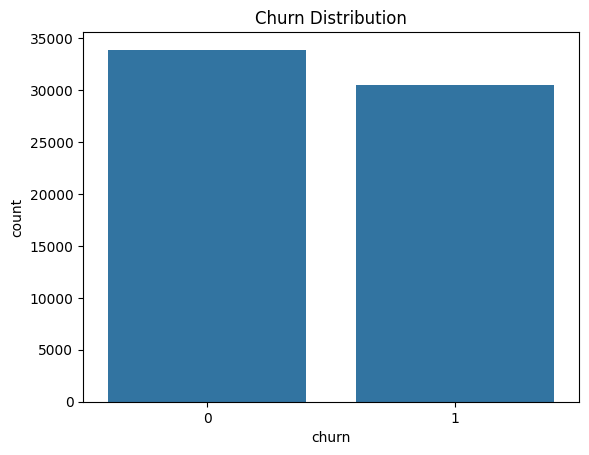

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='churn', data=df)
plt.title("Churn Distribution")

plt.savefig('../visuals/churn_distribution.png')
plt.show()

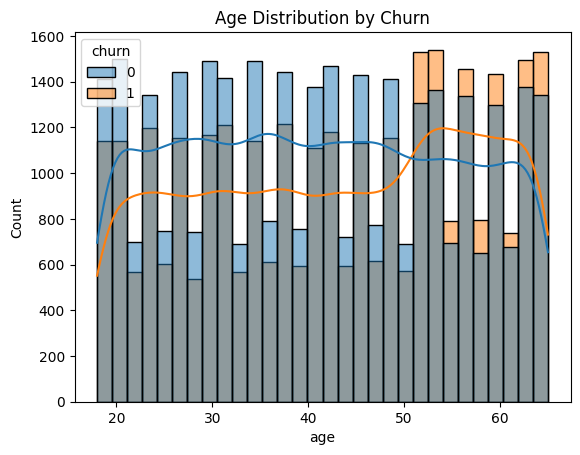

In [17]:
sns.histplot(data=df, x='age', hue='churn', bins=30, kde=True)
plt.title("Age Distribution by Churn")

plt.savefig('../visuals/age_vs_churn.png')
plt.show()

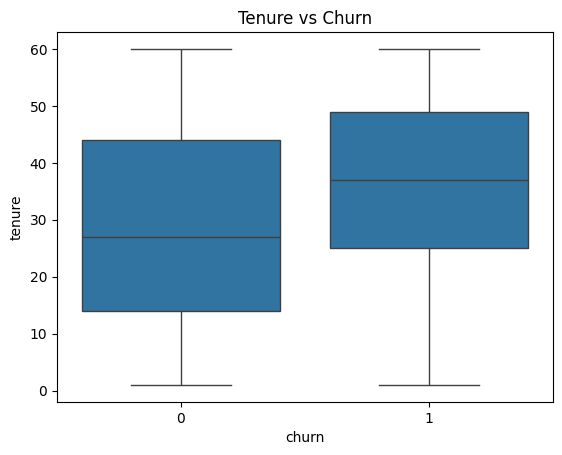

In [18]:
sns.boxplot(x='churn', y='tenure', data=df)
plt.title("Tenure vs Churn")

plt.savefig('../visuals/tenure_vs_churn.png')
plt.show()

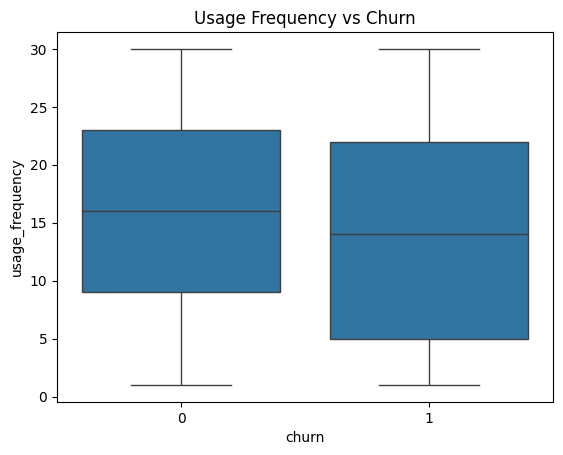

In [20]:
sns.boxplot(x='churn', y='usage_frequency', data=df)
plt.title("Usage Frequency vs Churn")

plt.savefig('../visuals/usage_vs_churn.png')
plt.show()

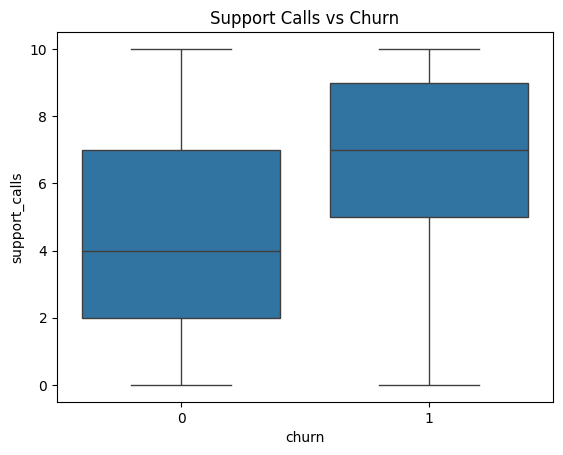

In [21]:
sns.boxplot(x='churn', y='support_calls', data=df)
plt.title("Support Calls vs Churn")

plt.savefig('../visuals/support_vs_churn.png')
plt.show()

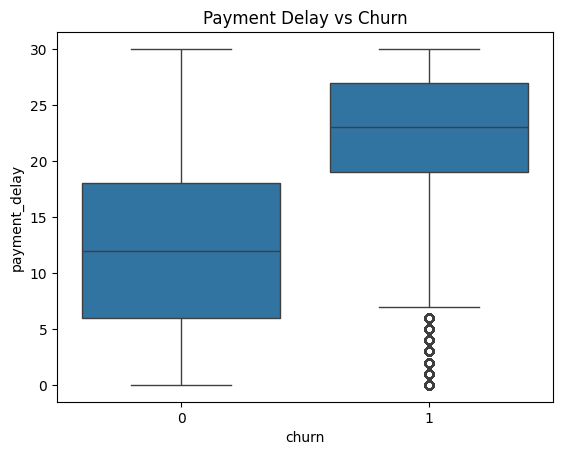

In [22]:
sns.boxplot(x='churn', y='payment_delay', data=df)
plt.title("Payment Delay vs Churn")

plt.savefig('../visuals/payment_vs_churn.png')
plt.show()

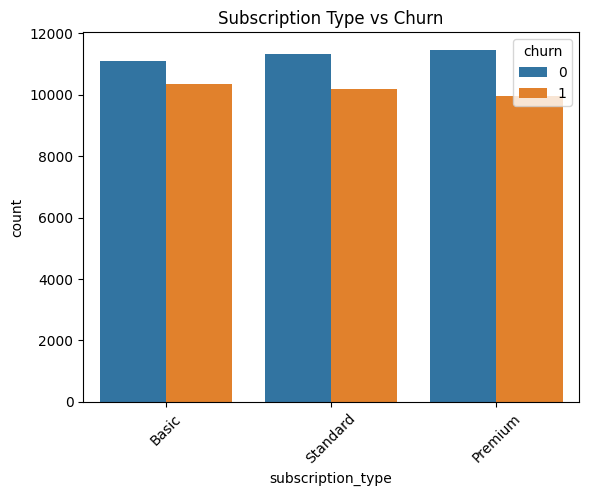

In [23]:
sns.countplot(x='subscription_type', hue='churn', data=df)
plt.xticks(rotation=45)
plt.title("Subscription Type vs Churn")

plt.savefig('../visuals/subscription_vs_churn.png')
plt.show()

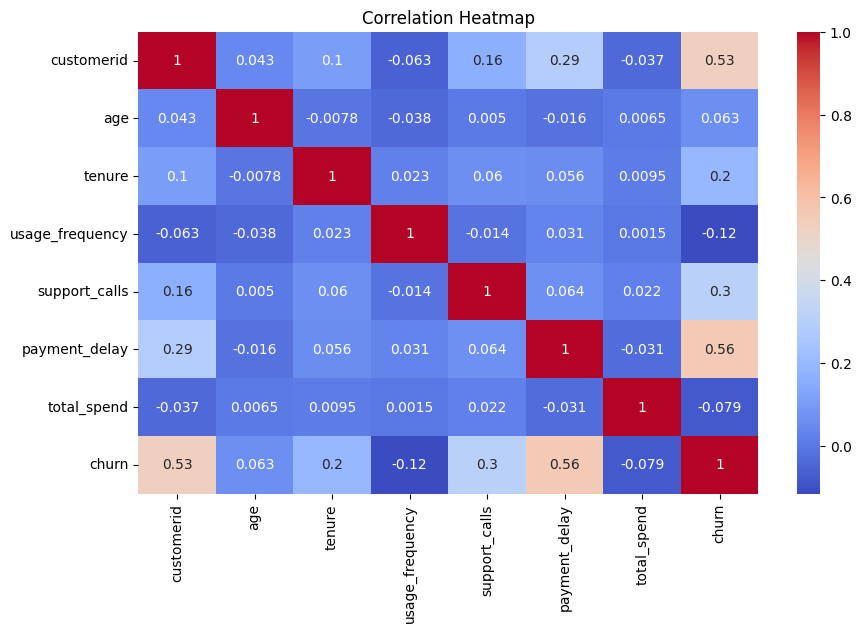

In [24]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")

plt.savefig('../visuals/correlation.png')
plt.show()

In [38]:
df.columns

Index(['age', 'tenure', 'usage_frequency', 'support_calls', 'payment_delay',
       'total_spend', 'churn', 'gender_Male', 'subscription_type_Premium',
       'subscription_type_Standard', 'contract_length_Monthly',
       'contract_length_Quarterly'],
      dtype='object')

In [39]:
df = df.drop(columns=['customerid', 'last_interaction'], errors='ignore')

In [40]:
df['churn'].value_counts()

churn
0    33881
1    30493
Name: count, dtype: int64

In [41]:
df = pd.get_dummies(df, drop_first=True)

In [42]:
X = df.drop('churn', axis=1)
y = df['churn']

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [44]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [45]:
from sklearn.linear_model import LogisticRegression

In [46]:
model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [47]:
y_pred = model.predict(X_test)

In [48]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8317669902912621


In [49]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[5656 1137]
 [1029 5053]]


In [50]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.83      0.84      6793
           1       0.82      0.83      0.82      6082

    accuracy                           0.83     12875
   macro avg       0.83      0.83      0.83     12875
weighted avg       0.83      0.83      0.83     12875



In [52]:
# Try another model

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [53]:
from sklearn.metrics import accuracy_score

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.9988349514563106


In [54]:
import pandas as pd

feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

print(feature_importance.head(10))

payment_delay                0.436231
support_calls                0.162800
tenure                       0.112662
usage_frequency              0.088080
gender_Male                  0.075367
total_spend                  0.049178
age                          0.040368
contract_length_Monthly      0.025205
contract_length_Quarterly    0.006695
subscription_type_Premium    0.001742
dtype: float64


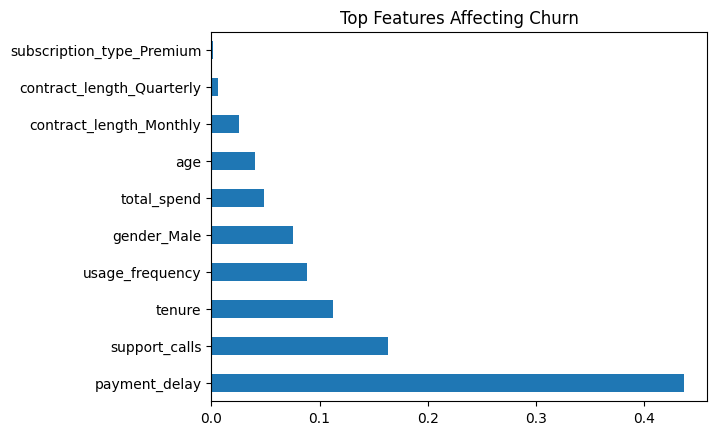

In [56]:
import matplotlib.pyplot as plt

feature_importance.head(10).plot(kind='barh')
plt.title("Top Features Affecting Churn")
plt.savefig('../visuals/top_features_affecting_churn.png')
plt.show()

In [57]:
import pickle

pickle.dump(model, open('../model.pkl', 'wb'))